
# S12 – Последовательности и время (PyTorch): базовая классификация временных рядов (TSC)

В этом ноутбуке показана базовая постановка задачи **time series classification (TSC)**.

**TSC** отличается от прогнозирования: вместо того чтобы предсказывать следующее значение, мы относим всю последовательность к одному из классов. Примеры реальных задач: распознавание активности по акселерометру, диагностика оборудования по вибрации, классификация ЭКГ.

Мы сгенерируем синтетический датасет из трёх классов с характерными формами сигналов (синус, меандр, пилообразный), обучим рекуррентную модель `GRU` для классификации и сравним её с простым baseline на статистических признаках.

> **Важно:** датасет намеренно спроектирован так, чтобы классы хорошо разделялись – это учебный пример, цель которого показать пайплайн, а не продемонстрировать "магию" нейросетей на сложных данных.



## 0. План

К концу ноутбука вы сможете:

1. Объяснить, чем **TSC** отличается от задачи прогнозирования (forecasting).
2. Генерировать синтетические временны́е ряды и анализировать их визуально.
3. Подготавливать последовательности, метки классов и `DataLoader` для PyTorch.
4. Строить модель `GRUClassifier`, понимать роль последнего скрытого состояния `h_n[-1]`.
5. Обучать и валидировать модель, строить кривые обучения.
6. Считать и интерпретировать `accuracy`, `precision`, `recall`, `F1` (macro).
7. Сравнивать нейросетевой подход с baseline на ручных признаках и объяснять разрыв в качестве.



## 1. Импорты и общие настройки


In [1]:
# Стандартные библиотеки для воспроизводимости и работы с массивами
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch: нейросетевые блоки и работа с данными
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# scikit-learn: разбиение данных, baseline-модель, метрики
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Настройки отображения графиков
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True


In [2]:
def set_seed(seed: int = 42):
    """Фиксирует все источники случайности для воспроизводимости результатов."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Используем GPU, если доступен, иначе – CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)


device = cpu



## 2. Генерация синтетического датасета

Каждый класс соответствует характерной форме сигнала:

| Класс | Форма         | Почему отличима |
|-------|---------------|-----------------|
| 0     | Синусоида     | Плавные переходы, симметричная форма |
| 1     | Меандр        | Резкие перепады ±1, большая дисперсия `std` |
| 2     | Пилообразный  | Линейный нарастающий/убывающий наклон |

Ко всем сигналам добавляется гауссов шум с σ = 0.4.  
Классы **намеренно хорошо разделимы** – это обеспечит быструю сходимость и наглядный результат в учебных целях.


In [3]:
def make_signal(class_id: int, seq_len: int = 80):
    """
    Генерирует один синтетический сигнал заданного класса.

    Класс 0: синусоида – непрерывные плавные колебания.
    Класс 1: меандр – бинарный сигнал ±1 с резкими перепадами.
    Класс 2: пилообразный – линейно нарастающий/спадающий сигнал.
    Ко всем классам добавляется гауссов шум σ=0.4.
    """
    t = np.linspace(0, 1, seq_len)
    noise = np.random.normal(0, 0.4, size=seq_len)

    if class_id == 0:
        # Синусоида с частотой 3 Гц
        y = np.sin(2 * np.pi * 3 * t) + noise
    elif class_id == 1:
        # Меандр: знак синусоиды даёт значения {-1, +1}
        y = np.sign(np.sin(2 * np.pi * 3 * t)) + noise
    else:
        # Пилообразный: дробная часть со смещением, значения в [-1, 1]
        y = 2 * (t - np.floor(t + 0.5))
        y = y + noise
    return y.astype(np.float32)


def build_dataset(n_per_class: int = 300, seq_len: int = 80):
    """
    Собирает полный датасет: генерирует n_per_class образцов для каждого из 3 классов.
    Возвращает X (N, seq_len) и y (N,).
    """
    X, y = [], []
    for class_id in range(3):
        for _ in range(n_per_class):
            X.append(make_signal(class_id, seq_len))
            y.append(class_id)
    X = np.stack(X)   # список → матрица (N, seq_len)
    y = np.array(y)
    return X, y

# Итого: 900 образцов × 80 временных шагов
X, y = build_dataset(n_per_class=300, seq_len=80)
print('X shape:', X.shape)
print('y shape:', y.shape)
print('classes:', np.unique(y))


X shape: (900, 80)
y shape: (900,)
classes: [0 1 2]


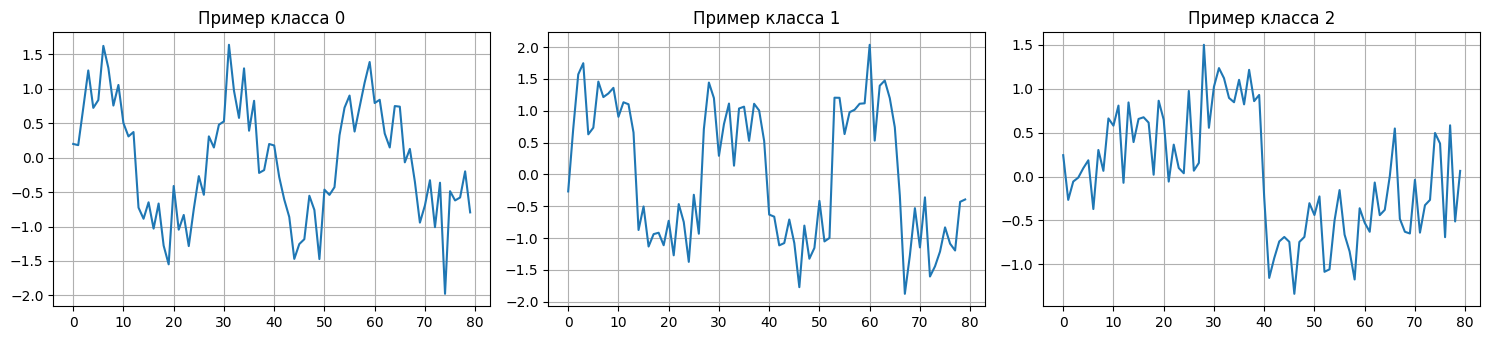

In [4]:
# Визуализируем по одному примеру каждого класса,
# чтобы убедиться в визуальной различимости форм сигналов
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for class_id in range(3):
    # Берём первый образец данного класса
    idx = np.where(y == class_id)[0][0]
    axes[class_id].plot(X[idx])
    axes[class_id].set_title(f'Пример класса {class_id}')
plt.tight_layout()
plt.show()



## 3. Разбиение на train / validation / test

Используем двухэтапное разбиение: сначала отделяем тест (20%), затем из оставшегося выделяем валидацию (20%).  
Параметр `stratify` гарантирует **равномерное распределение классов** в каждой части – это особенно важно при сбалансированном датасете, чтобы показатели на val и test были репрезентативными.


In [5]:
# Шаг 1: отделяем тестовую выборку (20% от всего датасета)
# stratify=y гарантирует равное соотношение классов в каждой части
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Шаг 2: из оставшихся 80% выделяем валидацию (ещё 20%)
# Итоговое разбиение: train ~64%, val ~16%, test ~20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print('train:', X_train.shape, y_train.shape)
print('val  :', X_val.shape, y_val.shape)
print('test :', X_test.shape, y_test.shape)


train: (576, 80) (576,)
val  : (144, 80) (144,)
test : (180, 80) (180,)



## 4. Dataset и DataLoader

Каждый образец – одномерный сигнал длиной 80. Мы добавляем размерность признака через `.unsqueeze(-1)`, чтобы получить тензор формы `(seq_len, 1)`. Именно такой формат ожидает `nn.GRU` при `batch_first=True`: `(batch, seq_len, input_size)`.


In [6]:
class SequenceClassificationDataset(Dataset):
    def __init__(self, X, y):
        # unsqueeze(-1): (N, seq_len) → (N, seq_len, 1)
        # GRU ожидает input_size=1 на каждом временном шаге
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        # Метки классов должны быть torch.long (int64) для CrossEntropyLoss
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Создаём датасеты для каждой части
train_ds = SequenceClassificationDataset(X_train, y_train)
val_ds   = SequenceClassificationDataset(X_val,   y_val)
test_ds  = SequenceClassificationDataset(X_test,  y_test)

# shuffle=True только для train: перемешивание улучшает сходимость
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Проверяем форму батча: (batch_size, seq_len, input_size)
xb, yb = next(iter(train_loader))
print('batch X:', xb.shape)   # ожидаем (32, 80, 1)
print('batch y:', yb.shape)   # ожидаем (32,)


batch X: torch.Size([32, 80, 1])
batch y: torch.Size([32])



## 5. Модель GRU для классификации

Архитектура классификатора на основе GRU:

```
Input (batch, 80, 1)
     ↓
GRU (hidden_size=32)  →  выход: all_outputs (batch, 80, 32) + h_n (1, batch, 32)
     ↓
h_n[-1]  ← берём последнее скрытое состояние – оно «накопило» информацию всей последовательности
     ↓
Linear(32 → 3)  →  logits по трём классам
```

**Почему `h_n[-1]`, а не последний элемент `out[:, -1, :]`?**  
Для однослойного GRU они эквивалентны, но `h_n[-1]` – более явный и педагогически правильный способ получить финальное состояние.


In [7]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, num_classes=3, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,   # вход/выход в формате (batch, seq, features)
            # dropout применяется только между слоями, поэтому нужен num_layers > 1
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # Линейный слой отображает скрытое состояние → логиты num_classes классов
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # out: (batch, seq_len, hidden_size) – выходы на каждом шаге
        # h_n: (num_layers, batch, hidden_size) – финальные скрытые состояния
        out, h_n = self.gru(x)

        # Берём скрытое состояние последнего слоя как представление всей последовательности
        last_hidden = h_n[-1]   # (batch, hidden_size)

        logits = self.fc(last_hidden)   # (batch, num_classes)
        return logits

model = GRUClassifier().to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


GRUClassifier(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)
parameters: 3459



## 6. Вспомогательные функции

Определим три функции:

- `compute_metrics` – подсчёт accuracy, precision, recall, F1 (macro-average по классам).
- `train_one_epoch` – один проход по обучающей выборке с обновлением весов.
- `evaluate` – проход без градиентов, возвращает loss, метрики и предсказания для дальнейшего анализа.


In [8]:
def compute_metrics(y_true, y_pred):
    """Считает accuracy и macro-averaged precision/recall/F1."""
    acc = accuracy_score(y_true, y_pred)
    # average='macro': метрика считается по каждому классу, затем усредняется
    # zero_division=0: если класс не встречается в предсказаниях – ставим 0, а не ошибку
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision_macro': p, 'recall_macro': r, 'f1_macro': f1}


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Один проход по обучающей выборке с обновлением весов модели."""
    model.train()   # включаем BatchNorm/Dropout в режим обучения
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()           # сбрасываем градиенты от предыдущего шага
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()                 # вычисляем градиенты
        optimizer.step()                # обновляем веса
        # накапливаем суммарный loss, взвешенный по числу образцов в батче
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)     # средний loss на образец


def evaluate(model, loader, criterion, device):
    """Оценка модели без обновления весов. Возвращает loss, метрики и предсказания."""
    model.eval()    # отключаем Dropout, BatchNorm переходит в inference-режим
    total_loss = 0.0
    all_preds, all_true = [], []
    with torch.no_grad():   # отключаем граф вычислений – экономим память и время
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            # argmax по оси классов → предсказанный класс
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.cpu().numpy())
    metrics = compute_metrics(all_true, all_preds)
    return total_loss / len(loader.dataset), metrics, np.array(all_true), np.array(all_preds)



## 7. Обучение модели

Используем:
- **Adam** (`lr=1e-3`) – адаптивный оптимизатор, хорошо работает «из коробки» на большинстве задач.
- **CrossEntropyLoss** – стандартная функция потерь для многоклассовой классификации; внутри совмещает `Softmax` и `NLLLoss`.
- **12 эпох** – на синтетических хорошо-разделимых данных этого достаточно для сходимости.

После каждой эпохи логируем train/val loss и val F1 – это позволяет следить за переобучением.


In [9]:
# CrossEntropyLoss = Softmax + NLLLoss; ожидает сырые логиты, не вероятности
criterion = nn.CrossEntropyLoss()
# Adam с lr=1e-3 – стандартный выбор для большинства задач
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 12
# Словарь для хранения истории обучения – понадобится для построения кривых
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    # _ – y_true и y_pred нам здесь не нужны, сохраняем только метрики
    val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1_macro'])

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1={val_metrics['f1_macro']:.4f}"
    )


Epoch 01 | train_loss=1.0784 | val_loss=1.0518 | val_acc=0.4028 | val_f1=0.2908
Epoch 02 | train_loss=1.0300 | val_loss=0.9968 | val_acc=0.3750 | val_f1=0.2622
Epoch 03 | train_loss=0.9624 | val_loss=0.9023 | val_acc=0.5625 | val_f1=0.5277
Epoch 04 | train_loss=0.8261 | val_loss=0.7039 | val_acc=0.8819 | val_f1=0.8797
Epoch 05 | train_loss=0.5903 | val_loss=0.4635 | val_acc=0.8750 | val_f1=0.8679
Epoch 06 | train_loss=0.3836 | val_loss=0.3074 | val_acc=0.9444 | val_f1=0.9438
Epoch 07 | train_loss=0.2709 | val_loss=0.2305 | val_acc=0.9514 | val_f1=0.9513
Epoch 08 | train_loss=0.2328 | val_loss=0.1910 | val_acc=0.9653 | val_f1=0.9653
Epoch 09 | train_loss=0.2013 | val_loss=0.1619 | val_acc=0.9722 | val_f1=0.9722
Epoch 10 | train_loss=0.1655 | val_loss=0.1424 | val_acc=0.9792 | val_f1=0.9792
Epoch 11 | train_loss=0.1537 | val_loss=0.1338 | val_acc=0.9653 | val_f1=0.9652
Epoch 12 | train_loss=0.1405 | val_loss=0.1294 | val_acc=0.9722 | val_f1=0.9722


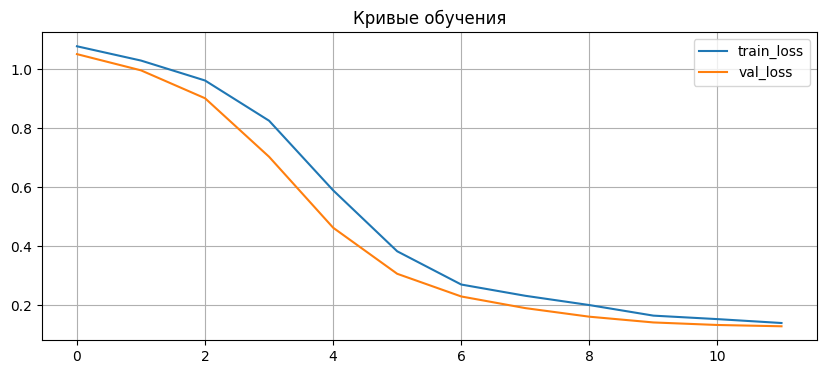

In [10]:
# Кривые обучения позволяют диагностировать переобучение:
# если val_loss перестаёт снижаться или растёт – модель переобучается
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'],   label='val_loss')
plt.legend()
plt.title('Кривые обучения')
plt.show()



## 8. Проверка на тестовой выборке

Финальная оценка – **только один раз** на отложенном тесте, который модель никогда не видела.  
Помимо сводных метрик, смотрим на `classification_report` (качество по каждому классу отдельно) и матрицу ошибок – это позволяет выявить, какие классы путаются чаще всего.


In [11]:
# Финальная оценка на тесте – вызываем только один раз,
# чтобы получить честную несмещённую оценку качества модели
test_loss, test_metrics, y_true_test, y_pred_test = evaluate(model, test_loader, criterion, device)
print('Test loss:', round(test_loss, 4))
print('Test metrics:', test_metrics)


Test loss: 0.1289
Test metrics: {'accuracy': 0.9555555555555556, 'precision_macro': 0.9584736251402918, 'recall_macro': 0.9555555555555556, 'f1_macro': 0.9554441659704818}


In [12]:
# classification_report: precision/recall/F1 по каждому классу отдельно
# digits=4 – выводим 4 знака после запятой для более точного сравнения
print(classification_report(y_true_test, y_pred_test, digits=4))

# Матрица ошибок: строки – истинные классы, столбцы – предсказанные
# Диагональ – правильные предсказания; внедиагональные элементы – ошибки
cm = confusion_matrix(y_true_test, y_pred_test)
print('Confusion matrix:')
print(cm)


              precision    recall  f1-score   support

           0     0.9815    0.8833    0.9298        60
           1     0.8939    0.9833    0.9365        60
           2     1.0000    1.0000    1.0000        60

    accuracy                         0.9556       180
   macro avg     0.9585    0.9556    0.9554       180
weighted avg     0.9585    0.9556    0.9554       180

Confusion matrix:
[[53  7  0]
 [ 1 59  0]
 [ 0  0 60]]



## 9. Baseline на простых статистических признаках

Прежде чем делать вывод о пользе нейросети, важно сравниться с **простым baseline**.  
Мы извлекаем 6 агрегированных признаков из каждого ряда:

| Признак | Что описывает |
|---------|---------------|
| `mean`  | Среднее значение |
| `std`   | Разброс (дисперсия) |
| `min`, `max` | Крайние значения |
| `slope` | Общий наклон (`X[-1] - X[0]`) |
| `energy`| Среднеквадратичная мощность |

Эти признаки **не описывают форму сигнала во времени**, тем не менее они достаточны для разделения трёх сильно различающихся классов.  
Если baseline работает почти так же хорошо, как GRU – это сигнал о том, что задача легко решается без рекуррентных сетей.


In [13]:
def extract_stat_features(X):
    """
    Извлекает 6 агрегированных признаков из каждого временного ряда.
    Эти признаки не учитывают порядок точек во времени, но отражают
    общую статистику формы сигнала.
    """
    mean   = X.mean(axis=1)              # среднее значение
    std    = X.std(axis=1)               # стандартное отклонение (разброс)
    min_   = X.min(axis=1)               # минимальное значение
    max_   = X.max(axis=1)               # максимальное значение
    slope  = X[:, -1] - X[:, 0]         # грубый наклон: последнее - первое значение
    energy = (X ** 2).mean(axis=1)       # среднеквадратичная мощность сигнала
    return np.stack([mean, std, min_, max_, slope, energy], axis=1)  # (N, 6)

# Применяем извлечение признаков ко всем трём частям датасета
X_train_feat = extract_stat_features(X_train)
X_val_feat   = extract_stat_features(X_val)
X_test_feat  = extract_stat_features(X_test)

# Логистическая регрессия как интерпретируемый линейный baseline
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_feat, y_train)

val_pred_bl  = baseline.predict(X_val_feat)
test_pred_bl = baseline.predict(X_test_feat)

print('Baseline val metrics: ', compute_metrics(y_val,   val_pred_bl))
print('Baseline test metrics:', compute_metrics(y_test,  test_pred_bl))


Baseline val metrics:  {'accuracy': 0.9027777777777778, 'precision_macro': 0.9055174385363065, 'recall_macro': 0.9027777777777777, 'f1_macro': 0.9028622999599731}
Baseline test metrics: {'accuracy': 0.8833333333333333, 'precision_macro': 0.8825614051420502, 'recall_macro': 0.8833333333333333, 'f1_macro': 0.8821754390031428}



## 10. Итоги

### Почему accuracy такая высокая?

Потому что мы намеренно выбрали **легко разделимые классы**: синусоида, меандр и пила – это принципиально разные формы сигналов. GRU распознаёт их с первых эпох, а статистический baseline тоже показывает высокое качество – достаточно одного признака `std`, чтобы уверенно разделить меандр от синусоиды.

На реальных данных (ЭКГ, вибрации, сенсоры) классы значительно перекрываются, шум сильнее, а преимущество нейросетей проявляется именно там.

### Ключевые выводы

1. **TSC – отдельная постановка:** вся последовательность → метка класса (не следующее значение).
2. **GRU для TSC:** финальное скрытое состояние `h_n[-1]` – компактное представление всей последовательности, подходящее для классификации.
3. **Baseline – обязательная точка отсчёта:** если статистические признаки дают ~тот же результат, нет смысла усложнять модель.
4. **Не смотрите только на accuracy:** при дисбалансе классов ориентируйтесь на macro-F1.
5. **Анализ ошибок по классам** (`classification_report`, матрица ошибок) важнее одной общей цифры.



## Задания для самостоятельной работы

1. **GRU vs LSTM:** замените `nn.GRU` на `nn.LSTM` (не забудьте, что `h_n` у LSTM – кортеж `(h, c)`). Сравните accuracy и время обучения.
2. **Длина последовательности:** попробуйте `seq_len = 20` и `seq_len = 200`. Как изменяется сложность задачи и качество?
3. **Сложный шум:** увеличьте σ с 0.4 до 1.5. При каком уровне шума классы начинают перекрываться и модели начинают ошибаться?
4. **Лучший baseline:** замените `LogisticRegression` на `RandomForestClassifier`. Сравните метрики и время обучения с GRU.
5. **1D-CNN:** реализуйте классификатор с `nn.Conv1d` + `AdaptiveAvgPool1d` вместо GRU. Как меняется архитектура и результат?
6. **Более сложные классы:** добавьте четвёртый класс – сигнал с нарастающей частотой (`chirp`). Усложнится ли задача для baseline?
